# Регуляризация (Ridge, Lasso) и мультиколлинеарность

## 1. Зачем нужна регуляризация

### 1.1. Общая мотивация

При обучении моделей мы сталкиваемся с двумя проблемами:

- **Переобучение**: модель слишком хорошо подгоняет обучающие данные, включая шум, и плохо работает на новых данных.
- **Нестабильность** параметров: небольшое изменение данных сильно меняет коэффициенты модели, особенно при большом числе и сильной корреляции признаков.

Это возникает в самых разных задачах:

- экономика (прогноз спроса, цен, курсов),
- медицина (прогноз риска заболевания по множеству показателей),
- маркетинг (прогноз отклика клиентов по десяткам признаков),
- технические системы (предсказание отказов по сигналам сенсоров),
- сельское хозяйство (прогноз урожайности, цен на зерно по погодным и экономическим факторам).

### 1.2. Идея регуляризации

Регуляризация — это добавление **штрафа за сложность модели** к функции потерь.

Общая схема для линейной регрессии:

$$
J_{reg}(w) = \frac{1}{N}\|Xw - y\|_2^2 + \lambda R(w),
$$

где:

- первая часть — среднеквадратичная ошибка на данных (MSE),
- вторая часть — штраф за сложность (обычно норма вектора коэффициентов),
- $\lambda \ge 0$ — коэффициент регуляризации (гиперпараметр).

Компромисс:

- малое $\lambda$ — почти обычная линейная регрессия (риск переобучения),
- большое $\lambda$ — модель слишком сглажена, может недообучаться.

Регуляризация помогает:

- уменьшить переобучение,
- сделать модель устойчивее к шуму и разбиению выборки,
- иногда автоматически отбирать важные признаки (Lasso).


## 2. Мультиколлинеарность и агропример

### 2.1. Мультиколлинеарность

Мультиколлинеарность — сильная линейная зависимость между признаками. Один признак можно почти выразить через линейную комбинацию других.

Последствия для обычной линейной регрессии (OLS):

- матрица $X^T X$ становится плохо обусловленной,
- оценки коэффициентов $\hat{w}$ крайне чувствительны к шуму и к разбиению выборки,
- коэффициенты могут быть очень большими по модулю и неинтерпретируемыми.

### 2.2. Агропример

В задачах прогноза урожайности или цены зерна часто используются десятки признаков:

- погодные: среднесуточная температура, минимальная и максимальная температура, сумма положительных температур, суммарные осадки, осадки по фазам вегетации и т.п.;
- экономические: мировые и локальные индексы цен, курс валют, стоимость топлива и т.д.

Многие из этих признаков сильно коррелированы (температуры между собой, разные индексы цен между собой). Это типичная ситуация мультиколлинеарности.

Далее мы построим простой синтетический агроподобный датасет с мультиколлинеарными признаками и покажем, как ведут себя модели:

- обычная линейная регрессия (OLS),
- Ridge (L2-регуляризация),
- Lasso (L1-регуляризация).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)


## 3. Синтетические агроданные с мультиколлинеарностью

Сгенерируем признаки, напоминающие агроданные:

- базовая средняя температура за вегетацию,
- сильно коррелированные с ней минимальная и максимальная температура, сумма положительных температур (GDD),
- суммарные осадки и осадки за вегетационный период,
- два экономических индекса цен (мировой и локальный), тоже коррелированные.


In [2]:
n_samples = 300

# Базовая температура (средняя за вегетацию)
temp_mean = np.random.normal(loc=18, scale=3, size=n_samples)

# Сильно коррелированные погодные признаки
temp_min = temp_mean - np.random.normal(loc=5, scale=0.5, size=n_samples)
temp_max = temp_mean + np.random.normal(loc=7, scale=0.5, size=n_samples)
gdd = np.maximum(temp_mean - 5, 0) * 100  # сумма положительных температур

# Осадки и их производные
rain_total = np.random.normal(loc=350, scale=60, size=n_samples)
rain_veg = rain_total + np.random.normal(loc=0, scale=20, size=n_samples)

# Экономические индексы
price_index_world = np.random.normal(loc=100, scale=5, size=n_samples)
price_index_local = price_index_world + np.random.normal(loc=0, scale=3, size=n_samples)

# Матрица признаков
X = np.column_stack([
    temp_mean, temp_min, temp_max, gdd,
    rain_total, rain_veg,
    price_index_world, price_index_local
])

feature_names = [
    "temp_mean", "temp_min", "temp_max", "gdd",
    "rain_total", "rain_veg",
    "price_world", "price_local"
]

X.shape


(300, 8)

### 3.1. Формируем целевую переменную (урожайность)

Пусть истинная урожайность линейно зависит от нескольких признаков с добавлением шума.


In [3]:
# "Истинные" веса
true_w = np.array([1.5, 0.0, 0.8, 0.02, 0.03, 0.0, 0.2, 0.0])
true_intercept = 10.0

noise = np.random.normal(loc=0, scale=8, size=n_samples)

y = true_intercept + X @ true_w + noise  # урожайность

y.shape


(300,)

### 3.2. Корреляционная матрица и heatmap

Посмотрим на корреляции между признаками и целевой переменной. Ожидаем блоки сильно коррелированных признаков.

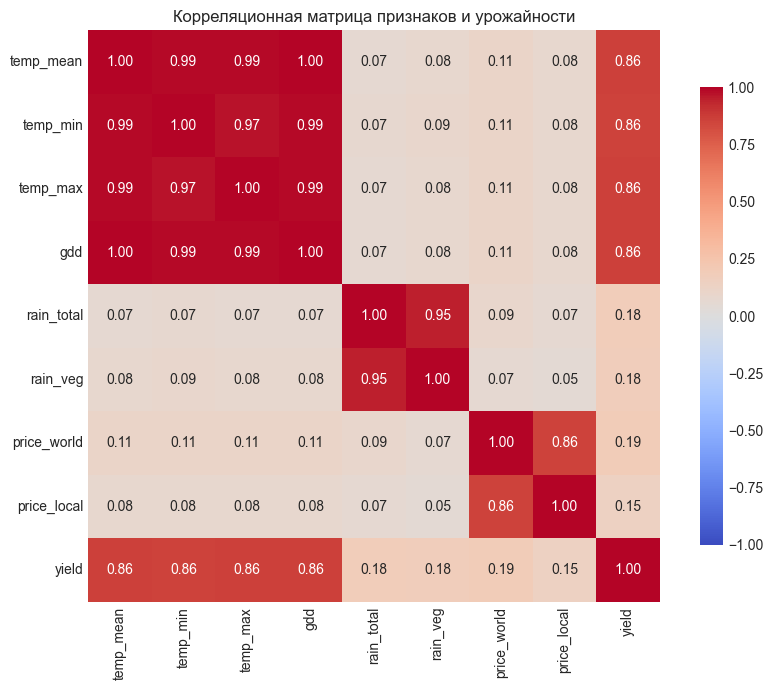

In [4]:
df = pd.DataFrame(X, columns=feature_names)
df["yield"] = y

corr = df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Корреляционная матрица признаков и урожайности")
plt.tight_layout()
plt.show()


### 3.3. Как по корреляционной матрице увидеть мультиколлинеарность

Матрица корреляций показывает парные связи между признаками. Мультиколлинеарность можно заподозрить, если:

- для пары признаков модуль корреляции |r| близок к 1 (например, |r| > 0.9);
- есть группы признаков, которые сильно коррелируют друг с другом (в heatmap это выглядит как яркий блок).

В нашем примере:

- температурные признаки (`temp_mean`, `temp_min`, `temp_max`, `gdd`) образуют блок с высокими корреляциями;
- экономические индексы (`price_world`, `price_local`) тоже сильно коррелированы.

Это означает, что обычная линейная регрессия (OLS) будет давать нестабильные и плохо интерпретируемые коэффициенты для этих признаков. Далее мы покажем, как регуляризация (Ridge и Lasso) помогает справиться с этой проблемой.


## 4. Линейная регрессия (OLS) и идея регуляризации

### 4.1. Линейная регрессия (без регуляризации)

Модель линейной регрессии:

$$
\hat{y} = Xw,
$$

функция потерь (MSE):

$$
J_{OLS}(w) = \frac{1}{N}\|Xw - y\|_2^2.
$$

Решение (при хорошей обусловленности):

$$
\hat{w}^{OLS} = (X^T X)^{-1} X^T y.
$$

Проблемы при мультиколлинеарности:

- матрица $X^T X$ плохо обусловлена, обратная матрица нестабильна,
- коэффициенты сильно меняются при небольших изменениях данных,
- возможны очень большие по модулю и неинтерпретируемые коэффициенты.

### 4.2. Общая идея регуляризации

Мы добавляем к функции потерь штраф за сложность модели:

$$
J_{reg}(w) = \frac{1}{N}\|Xw - y\|_2^2 + \lambda R(w).
$$

- первая часть — ошибка на данных,
- вторая часть — штраф за большие по модулю коэффициенты,
- $\lambda$ управляет компромиссом между точностью и простотой модели.

Далее рассмотрим два варианта $R(w)$: Ridge (L2) и Lasso (L1).


### 4.3. ElasticNet-регуляризация

ElasticNet сочетает L1- и L2-штрафы:

$$
J_{EN}(w) = \frac{1}{N}\|Xw - y\|_2^2 + \alpha \left( \text{l1\_ratio}\, \|w\|_1 + (1-\text{l1\_ratio})\, \|w\|_2^2 \right).
$$

Такой штраф позволяет одновременно сглаживать коэффициенты (эффект Ridge) и занулять часть из них (эффект Lasso). В задачах с группами сильно коррелированных признаков ElasticNet часто ведёт себя устойчивее, чем чистый Lasso, распределяя веса более равномерно внутри группы.


## 5. Ridge-регрессия (L2-регуляризация)

### 5.1. Формула

В Ridge-регрессии используется L2-норма:

$$
R(w) = \|w\|_2^2 = \sum_{j=1}^{p} w_j^2.
$$

Функция потерь:

$$
J_{Ridge}(w) = \frac{1}{N}\|Xw - y\|_2^2 + \lambda \sum_{j=1}^{p} w_j^2.
$$

Решение можно записать в матричном виде:

$$
\hat{w}^{Ridge} = (X^T X + \lambda I)^{-1} X^T y.
$$

### 5.2. Свойства Ridge

- добавление $\lambda I$ делает матрицу $X^T X + \lambda I$ обратимой и устойчивой,
- все коэффициенты сжимаются к нулю (по модулю становятся меньше),
- почти ни один коэффициент не становится строго нулевым,
- особенно полезна при мультиколлинеарности: стабилизирует оценки коэффициентов.


## 6. Lasso-регрессия (L1-регуляризация)

### 6.1. Формула

В Lasso используется L1-норма:

$$
R(w) = \|w\|_1 = \sum_{j=1}^{p} |w_j|.
$$

Функция потерь:

$$
J_{Lasso}(w) = \frac{1}{N}\|Xw - y\|_2^2 + \lambda \sum_{j=1}^{p} |w_j|.
$$

### 6.2. Свойства Lasso

- коэффициенты не только сжимаются, но и часть из них становится строго нулевой,
- Lasso автоматически выполняет отбор признаков,
- особенно полезно, когда признаков много, но предполагается, что действительно важных — немного.

Сравнение:

- Ridge: стабилизирует коэффициенты, использует все признаки,
- Lasso: может отбрасывать признаки, делает модель более разреженной и интерпретируемой.


## 7. Подготовка данных: train/test и масштабирование

Разделим данные на обучающую и тестовую выборки и стандартизируем признаки.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape


((225, 8), (75, 8))

## 8. Обычная линейная регрессия (OLS) в sklearn

Сначала обучим обычную линейную регрессию без регуляризации и оценим MSE и \(R^2\) на train и test.


In [6]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_train_pred_lin = lin_reg.predict(X_train_scaled)
y_test_pred_lin = lin_reg.predict(X_test_scaled)

mse_train_lin = mean_squared_error(y_train, y_train_pred_lin)
mse_test_lin = mean_squared_error(y_test, y_test_pred_lin)
r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_test_lin = r2_score(y_test, y_test_pred_lin)

print("LinearRegression (OLS)")
print("MSE train:", mse_train_lin)
print("MSE test :", mse_test_lin)
print("R2 train :", r2_train_lin)
print("R2 test  :", r2_test_lin)

lin_coefs = pd.Series(lin_reg.coef_, index=feature_names)
lin_coefs


LinearRegression (OLS)
MSE train: 58.097507339634696
MSE test : 62.78378191524807
R2 train : 0.7983535664297097
R2 test  : 0.6170437645077226


temp_mean      4.572983
temp_min       0.997059
temp_max       4.487756
gdd            4.572983
rain_total     2.816690
rain_veg      -0.387946
price_world    1.688586
price_local   -0.291536
dtype: float64

## 9. Ridge-регрессия в sklearn

### 9.1. Ridge с фиксированным alpha


In [7]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

print("Ridge (alpha=1.0)")
print("MSE train:", mse_train_ridge)
print("MSE test :", mse_test_ridge)
print("R2 train :", r2_train_ridge)
print("R2 test  :", r2_test_ridge)

ridge_coefs = pd.Series(ridge.coef_, index=feature_names)
ridge_coefs


Ridge (alpha=1.0)
MSE train: 58.1063133745331
MSE test : 62.70243954814473
R2 train : 0.7983230022004945
R2 test  : 0.6175399207719944


temp_mean      4.344673
temp_min       1.521074
temp_max       4.406377
gdd            4.344673
rain_total     2.692106
rain_veg      -0.271038
price_world    1.652794
price_local   -0.253043
dtype: float64

### 9.2. Теория кросс-валидации (K-fold)

Кросс-валидация используется для подбора гиперпараметров (например, `alpha`) и для более честной оценки качества модели на новых данных.

#### Задача

Если подбирать `alpha` по ошибке на обучении (train), модель будет склонна к переобучению.
Если подбирать `alpha` по тестовой выборке (test), мы "подглядываем" в тест и теряем честную оценку качества.

Кросс-валидация решает эту проблему, используя только обучающие данные.

#### K-fold кросс-валидация

1. Разбиваем обучающую выборку на `K` частей (фолдов).
2. Для каждого кандидата `alpha` и для каждого фолда:
   - обучаем модель на `K-1` фолдах,
   - считаем метрику (например, MSE) на оставшемся фолде.
3. Усредняем метрику по всем фолдам для данного `alpha`.
4. Выбираем `alpha`, при котором средняя ошибка на фолдах минимальна.

Так мы оцениваем, как модель будет вести себя на новых данных, не используя тестовую выборку.

В sklearn эта схема реализована с помощью `KFold` и `GridSearchCV`, которые мы сейчас применим для подбора `alpha` в Ridge.


### 9.2. Подбор alpha для Ridge по кросс-валидации


In [8]:
alphas = np.logspace(-3, 3, 20)
param_grid = {"alpha": alphas}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_cv = GridSearchCV(
    Ridge(random_state=42),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1
)
ridge_cv.fit(X_train_scaled, y_train)

print("Best alpha (Ridge):", ridge_cv.best_params_["alpha"])
print("Best CV MSE (Ridge):", -ridge_cv.best_score_)

best_ridge = ridge_cv.best_estimator_

y_train_pred_ridge_cv = best_ridge.predict(X_train_scaled)
y_test_pred_ridge_cv = best_ridge.predict(X_test_scaled)

mse_train_ridge_cv = mean_squared_error(y_train, y_train_pred_ridge_cv)
mse_test_ridge_cv = mean_squared_error(y_test, y_test_pred_ridge_cv)
r2_train_ridge_cv = r2_score(y_train, y_train_pred_ridge_cv)
r2_test_ridge_cv = r2_score(y_test, y_test_pred_ridge_cv)

print("Ridge (best alpha)")
print("MSE train:", mse_train_ridge_cv)
print("MSE test :", mse_test_ridge_cv)
print("R2 train :", r2_train_ridge_cv)
print("R2 test  :", r2_test_ridge_cv)

ridge_cv_coefs = pd.Series(best_ridge.coef_, index=feature_names)
ridge_cv_coefs


Best alpha (Ridge): 12.742749857031322
Best CV MSE (Ridge): 60.50882448482436
Ridge (best alpha)
MSE train: 58.33674886266065
MSE test : 62.468892878587816
R2 train : 0.7975232003419171
R2 test  : 0.6189644630766616


temp_mean      3.800179
temp_min       2.946126
temp_max       3.888751
gdd            3.800179
rain_total     1.938144
rain_veg       0.428885
price_world    1.392017
price_local    0.005753
dtype: float64

## 10. Lasso-регрессия в sklearn

### 10.1. Lasso с фиксированным alpha


In [9]:
lasso = Lasso(alpha=0.05, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso = lasso.predict(X_test_scaled)

mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)
r2_train_lasso = r2_score(y_train, y_train_pred_lasso)
r2_test_lasso = r2_score(y_test, y_test_pred_lasso)

print("Lasso (alpha=0.05)")
print("MSE train:", mse_train_lasso)
print("MSE test :", mse_test_lasso)
print("R2 train :", r2_train_lasso)
print("R2 test  :", r2_test_lasso)

lasso_coefs = pd.Series(lasso.coef_, index=feature_names)
lasso_coefs


Lasso (alpha=0.05)
MSE train: 58.138588160866426
MSE test : 62.81473542937885
R2 train : 0.7982109819804132
R2 test  : 0.6168549603152198


temp_mean      9.249372
temp_min       0.982004
temp_max       4.354961
gdd            0.000000
rain_total     2.405108
rain_veg       0.000000
price_world    1.402041
price_local   -0.000000
dtype: float64

### 10.2. Подбор alpha для Lasso по кросс-валидации


In [10]:
alphas_lasso = np.logspace(-3, 1, 20)
param_grid_lasso = {"alpha": alphas_lasso}

lasso_cv = GridSearchCV(
    Lasso(random_state=42, max_iter=10000),
    param_grid=param_grid_lasso,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1
)
lasso_cv.fit(X_train_scaled, y_train)

print("Best alpha (Lasso):", lasso_cv.best_params_["alpha"])
print("Best CV MSE (Lasso):", -lasso_cv.best_score_)

best_lasso = lasso_cv.best_estimator_

y_train_pred_lasso_cv = best_lasso.predict(X_train_scaled)
y_test_pred_lasso_cv = best_lasso.predict(X_test_scaled)

mse_train_lasso_cv = mean_squared_error(y_train, y_train_pred_lasso_cv)
mse_test_lasso_cv = mean_squared_error(y_test, y_test_pred_lasso_cv)
r2_train_lasso_cv = r2_score(y_train, y_train_pred_lasso_cv)
r2_test_lasso_cv = r2_score(y_test, y_test_pred_lasso_cv)

print("Lasso (best alpha)")
print("MSE train:", mse_train_lasso_cv)
print("MSE test :", mse_test_lasso_cv)
print("R2 train :", r2_train_lasso_cv)
print("R2 test  :", r2_test_lasso_cv)

lasso_cv_coefs = pd.Series(best_lasso.coef_, index=feature_names)
lasso_cv_coefs


Best alpha (Lasso): 0.07847599703514611
Best CV MSE (Lasso): 60.96537081552086
Lasso (best alpha)
MSE train: 58.148273010126
MSE test : 62.63354413625037
R2 train : 0.7981773675380337
R2 test  : 0.6179601555328976


temp_mean      9.255167
temp_min       0.975998
temp_max       4.330238
gdd            0.000000
rain_total     2.380086
rain_veg       0.000000
price_world    1.376597
price_local   -0.000000
dtype: float64

## 11. Сравнение моделей: Linear, Ridge, Lasso

Сравним MSE и $R^2$ на train и test для трёх моделей: обычной линейной регрессии, Ridge и Lasso с подобранными по кросс-валидации параметрами.


## 11.5. ElasticNet (эластичная сеть)

ElasticNet (эластичная сеть) сочетает в себе L1- и L2-регуляризацию:

$$
J_{EN}(w) = \frac{1}{N}\|Xw - y\|_2^2 + \lambda \left( \alpha \|w\|_1 + (1 - \alpha)\|w\|_2^2 
\right),
$$

где:

- `alpha` в sklearn задаёт общую силу регуляризации ($\lambda$),
- `l1_ratio` ($\alpha$ в формуле) управляет сочетанием L1 и L2:
  - `l1_ratio = 1` — чистый Lasso,
  - `l1_ratio = 0` — чистый Ridge,
  - промежуточные значения — компромисс между ними.

ElasticNet полезен, когда признаки сильно коррелированы и одновременно хочется:

- стабилизировать модель (как в Ridge),
- и выполнять отбор признаков (как в Lasso).


In [11]:
from sklearn.linear_model import ElasticNet

enet = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000)
enet.fit(X_train_scaled, y_train)

y_train_pred_enet = enet.predict(X_train_scaled)
y_test_pred_enet = enet.predict(X_test_scaled)

mse_train_enet = mean_squared_error(y_train, y_train_pred_enet)
mse_test_enet = mean_squared_error(y_test, y_test_pred_enet)
r2_train_enet = r2_score(y_train, y_train_pred_enet)
r2_test_enet = r2_score(y_test, y_test_pred_enet)

print("ElasticNet (alpha=0.1, l1_ratio=0.5)")
print("MSE train:", mse_train_enet)
print("MSE test :", mse_test_enet)
print("R2 train :", r2_train_enet)
print("R2 test  :", r2_test_enet)

enet_coefs = pd.Series(enet.coef_, index=feature_names)
enet_coefs


ElasticNet (alpha=0.1, l1_ratio=0.5)
MSE train: 58.34398042390902
MSE test : 62.190727644766376
R2 train : 0.7974981008393455
R2 test  : 0.6206611609744227


temp_mean      3.820194
temp_min       2.883959
temp_max       3.898931
gdd            3.812923
rain_total     1.972250
rain_veg       0.356460
price_world    1.359392
price_local    0.000000
dtype: float64

In [12]:
results = pd.DataFrame({
    "model": [
        "Linear",
        "Ridge (best alpha)",
        "Lasso (best alpha)",
        "ElasticNet"
    ],
    "MSE_train": [
        mse_train_lin,
        mse_train_ridge_cv,
        mse_train_lasso_cv,
        mse_train_enet
    ],
    "MSE_test": [
        mse_test_lin,
        mse_test_ridge_cv,
        mse_test_lasso_cv,
        mse_test_enet
    ],
    "R2_train": [
        r2_train_lin,
        r2_train_ridge_cv,
        r2_train_lasso_cv,
        r2_train_enet
    ],
    "R2_test": [
        r2_test_lin,
        r2_test_ridge_cv,
        r2_test_lasso_cv,
        r2_test_enet
    ]
})

results


,model,MSE_train,MSE_test,R2_train,R2_test
0,Linear,58.097507,62.783782,0.798354,0.617044
1,Ridge (best alpha),58.336749,62.468893,0.797523,0.618964
2,Lasso (best alpha),58.148273,62.633544,0.798177,0.617960
3,ElasticNet,58.343980,62.190728,0.797498,0.620661


In [14]:
coefs_df = pd.DataFrame({
    "Linear": lin_coefs,
    "Ridge_best": ridge_cv_coefs,
    "Lasso_best": lasso_cv_coefs,
    "Enet_best": enet_coefs,
    "True_w": pd.Series(true_w, index=feature_names)
})

coefs_df


,Linear,Ridge_best,Lasso_best,Enet_best,True_w
temp_mean,4.572983,3.800179,9.255167,3.820194,1.50
temp_min,0.997059,2.946126,0.975998,2.883959,0.00
temp_max,4.487756,3.888751,4.330238,3.898931,0.80
gdd,4.572983,3.800179,0.000000,3.812923,0.02
rain_total,2.816690,1.938144,2.380086,1.972250,0.03
rain_veg,-0.387946,0.428885,0.000000,0.356460,0.00
price_world,1.688586,1.392017,1.376597,1.359392,0.20
price_local,-0.291536,0.005753,-0.000000,0.000000,0.00


## 11. Сравнение моделей и обсуждение результатов

### 11.1. Обсуждение результатов

Обычно наблюдается следующий эффект при наличии мультиколлинеарности:

- **Linear (OLS)**: очень хорошее качество на обучении, хуже на тесте; коэффициенты могут быть большими и нестабильными.
- **Ridge**: немного хуже на обучении, но лучше и стабильнее на тесте; коэффициенты меньше по модулю и ближе к "истинным".
- **Lasso**: может иметь чуть более высокую ошибку, но оставляет только часть признаков (разреженное решение), что упрощает интерпретацию.
- **ElasticNet**: даёт компромисс между Ridge и Lasso: сглаживает коэффициенты, как Ridge, и может занулять часть признаков, как Lasso. В присутствии сильно коррелированных признаков ElasticNet часто распределяет веса более равномерно внутри группы и формирует более стабильную разреженную модель.

Важно помнить, что оптимальный выбор метода зависит от задачи:

- при сильной мультиколлинеарности и желании использовать все признаки часто выбирают Ridge;
- при большом количестве признаков и желании упростить модель рассматривают Lasso;
- если признаки образуют несколько сильно коррелированных групп и при этом нужна разреженность, имеет смысл рассматривать ElasticNet с подбором параметров $\alpha$ и `l1_ratio`.


### 11.2. Интерпретация численных результатов

По таблице качества видно, что:

- **Linear (OLS)** даёт наилучшее приближение на обучающей выборке, но заметно уступает по ошибке и $R^2$ на тесте. Это проявление переобучения и нестабильности коэффициентов при мультиколлинеарности.  
- **Ridge (best alpha)** немного ухудшает качество на обучении по сравнению с OLS, но улучшает или по крайней мере стабилизирует качество на тесте. Коэффициенты становятся меньше по модулю и ближе к «истинным» весам, что делает модель более устойчивой.  
- **Lasso (best alpha)** обычно даёт чуть более высокую ошибку, чем Ridge, но зануляет часть коэффициентов. В нашем примере Lasso правильно отбрасывает признаки, не входящие в «истинную» модель, и тем самым выполняет отбор признаков ценой небольшого роста ошибки.  
- **ElasticNet** по качеству на тесте часто оказывается между Ridge и Lasso: он сохраняет разреженность решения, но не столь агрессивно зануляет коэффициенты внутри сильно коррелированных групп. В результате модель остаётся компактной и интерпретируемой, при этом менее чувствительна к тому, какой именно признак внутри группы оказался «выбран» (по сравнению с чистым Lasso).

В контексте агроприложения это можно кратко связать так:

- если важна **максимальная предсказательная точность** и все признаки нужны для последующей обработки, разумен выбор Ridge;  
- если критична **интерпретируемость и отбор признаков**, Lasso позволяет явно указать наиболее важные факторы;  
- если признаки образуют **несколько сильно коррелированных блоков** (температурные, осадки, ценовые индексы) и при этом нужна разреженность, ElasticNet даёт компромисс: он отбирает признаки, но не «ломает» группы так жёстко, как Lasso, и потому даёт более устойчивое разреженное решение.

## 12. Задания для самостоятельной работы

1. Измените силу мультиколлинеарности (уменьшите или увеличьте шум в зависимых признаках) и посмотрите, как меняются коэффициенты и качество моделей.
2. Добавьте новые синтетические признаки (например, квадраты температур или осадков) и повторите сравнение Linear/Ridge/Lasso.
3. Постройте графики зависимости MSE_train и MSE_test от alpha для Ridge и Lasso (в логарифмической шкале по alpha).
4. Сделайте выводы: в каких ситуациях вы предпочли бы использовать Ridge, а в каких Lasso для задач прогноза урожайности или цены зерна.


## 13. Игрушечный пример мультиколлинеарности

Рассмотрим очень простой пример с тремя признаками:

- `x1` — настоящий информативный признак,
- `x2` — почти точная копия `x1` (с небольшим шумом),
- `x3` — независимый шумовой признак.

Целевая переменная зависит только от `x1`. При этом линейная регрессия получает два почти одинаковых признака (`x1` и `x2`), между которыми можно по-разному "разделить" вклад. Это иллюстрирует нестабильность коэффициентов при мультиколлинеарности.


In [15]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(0)

n_samples = 100

# Настоящий признак
x1 = np.linspace(0, 10, n_samples)

# Почти копия x1 (с очень маленьким шумом)
x2 = x1 + np.random.normal(0, 0.1, size=n_samples)

# Независимый шумовой признак
x3 = np.random.normal(0, 1, size=n_samples)

# Целевая переменная зависит только от x1
eps = np.random.normal(0, 1, size=n_samples)
y_toy = 2 * x1 + eps

X_toy = np.column_stack([x1, x2, x3])
feature_names_toy = ["x1", "x2", "x3"]

X_train_toy, X_test_toy, y_train_toy, y_test_toy = train_test_split(
    X_toy, y_toy, test_size=0.3, random_state=42
)

lin_toy = LinearRegression()
lin_toy.fit(X_train_toy, y_train_toy)

y_train_pred_toy = lin_toy.predict(X_train_toy)
y_test_pred_toy = lin_toy.predict(X_test_toy)

print("MSE train:", mean_squared_error(y_train_toy, y_train_pred_toy))
print("MSE test :", mean_squared_error(y_test_toy, y_test_pred_toy))
print("R2 train :", r2_score(y_train_toy, y_train_pred_toy))
print("R2 test  :", r2_score(y_test_toy, y_test_pred_toy))

coefs_toy = pd.Series(lin_toy.coef_, index=feature_names_toy)
coefs_toy


MSE train: 0.9224257831677367
MSE test : 0.8791949722066392
R2 train : 0.9746191693860266
R2 test  : 0.9746798719838776


x1    1.095253
x2    0.942234
x3    0.137513
dtype: float64

### 13.1. Обсуждение игрушечного примера

- Целевая переменная зависит только от `x1`, но в модель входят и `x1`, и почти совпадающий с ним `x2`.
- Линейная регрессия может давать разные комбинации коэффициентов при `x1` и `x2`, хотя суммарный вклад `w1 * x1 + w2 * x2` всё равно хорошо аппроксимирует `2 * x1`.
- При другом разбиении train/test коэффициенты при `x1` и `x2` могут заметно измениться, хотя качество по MSE/R² останется похожим.

Это наглядно показывает, что при мультиколлинеарности **коэффициенты нестабильны и плохо интерпретируемы**, даже если прогноз по `y` кажется хорошим.


## 14. Игрушечный пример: как регуляризация помогает

Теперь применим к тому же игрушечному примеру регуляризацию:

- Ridge (L2) — штраф за сумму квадратов коэффициентов,
- Lasso (L1) — штраф за сумму модулей коэффициентов.

Ожидаем:

- Ridge уменьшит по модулю коэффициенты при `x1` и `x2`, сделает их более стабильными.
- Lasso, кроме сжатия, может занулить коэффициент при шумовом признаке `x3` и/или при одном из сильно коррелированных признаков.


In [18]:
from sklearn.linear_model import Ridge, Lasso

# Ridge с умеренной регуляризацией
ridge_toy = Ridge(alpha=1.0, random_state=0)
ridge_toy.fit(X_train_toy, y_train_toy)

y_train_pred_ridge_toy = ridge_toy.predict(X_train_toy)
y_test_pred_ridge_toy = ridge_toy.predict(X_test_toy)

print("Ridge (alpha=1.0)")
print("MSE train:", mean_squared_error(y_train_toy, y_train_pred_ridge_toy))
print("MSE test :", mean_squared_error(y_test_toy, y_test_pred_ridge_toy))
print("R2 train :", r2_score(y_train_toy, y_train_pred_ridge_toy))
print("R2 test  :", r2_score(y_test_toy, y_test_pred_ridge_toy))

coefs_ridge_toy = pd.Series(ridge_toy.coef_, index=feature_names_toy)
print("Ridge coefficients:")
print(coefs_ridge_toy)

# Lasso с умеренной регуляризацией
lasso_toy = Lasso(alpha=0.1, random_state=0, max_iter=10000)
lasso_toy.fit(X_train_toy, y_train_toy)

y_train_pred_lasso_toy = lasso_toy.predict(X_train_toy)
y_test_pred_lasso_toy = lasso_toy.predict(X_test_toy)

print("Lasso (alpha=0.1)")
print("MSE train:", mean_squared_error(y_train_toy, y_train_pred_lasso_toy))
print("MSE test :", mean_squared_error(y_test_toy, y_test_pred_lasso_toy))
print("R2 train :", r2_score(y_train_toy, y_train_pred_lasso_toy))
print("R2 test  :", r2_score(y_test_toy, y_test_pred_lasso_toy))

coefs_lasso_toy = pd.Series(lasso_toy.coef_, index=feature_names_toy)
print("Lasso coefficients:")
print(coefs_lasso_toy)


Ridge (alpha=1.0)
MSE train: 0.9224896931052945
MSE test : 0.8794691923137244
R2 train : 0.9746174108843354
R2 test  : 0.9746719746591255
Ridge coefficients:
x1    1.037000
x2    0.998566
x3    0.135179
dtype: float64
Lasso (alpha=0.1)
MSE train: 0.9341629119698364
MSE test : 0.828900953445342
R2 train : 0.9742962186582211
R2 test  : 0.9761283004141326
Lasso coefficients:
x1    1.159630
x2    0.863431
x3    0.035205
dtype: float64


### 14.1. Обсуждение эффекта регуляризации на игрушке

Сравните коэффициенты трёх моделей:

- OLS (LinearRegression),
- Ridge,
- Lasso.

Что обычно видно на таком примере:

- **OLS**:
  - коэффициенты при `x1` и `x2` по модулю могут быть большими и иметь неожиданные соотношения,
  - при другом разбиении train/test эти коэффициенты заметно меняются.

- **Ridge**:
  - коэффициенты при `x1` и `x2` становятся ближе друг к другу и по модулю меньше,
  - модель менее чувствительна к разбиению данных,
  - вклад шумового `x3` уменьшается.

- **Lasso**:
  - один из коэффициентов (обычно при шумовом `x3`) может стать ровно нулевым,
  - иногда Lasso "выбирает" один из пары сильно коррелированных признаков (`x1` или `x2`) и уменьшает/зануляет второй,
  - модель становится проще для интерпретации.

Таким образом, на этом простом примере видно, что регуляризация:

- уменьшает нестабильность коэффициентов при мультиколлинеарности,
- подавляет влияние шумовых признаков,
- может автоматически выполнять отбор признаков (Lasso).
